# System identification of the voice coil actuator from scheduled-amplitude chirps

Step 1: plot one scheduled chirp run from `gcsc_data/`. The plotting code below is copied from
`scripts/plot_voice_coil_log.py`. Its `main()` is `plot_log(path)` here, because a notebook has no
command-line argument. Change `RUN_FILE` to look at another run.

In [1]:
RUN_FILE = "gcsc_data/voice_coil_log_chirpsched_0.0s2.0A-30.0s6.0A-60.0s15.0A-r30.0s_10.0to55.0Hz_120.0s_20261002_102726.csv"

## Imports and plot settings

In [2]:
import csv
import glob
import math
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.widgets import CheckButtons

# One entry per axis:
#   (y-axis label, checkboxes?, {trace label: (csv column, colour)})
AXES = [
    (
        "current (A)",
        True,
        {
            "actual current": ("actual_current_A", "tab:blue"),
            "target current": ("target_current_A", "tab:orange"),
            "demand current": ("demand_current_A", "tab:green"),
        },
    ),
    (
        "x (mm)",
        False,
        {
            "ai1_mm": (None, "tab:brown"),
            "ai1_mm_lp": (None, "black"),
        },
    ),
    (
        "ai2_g (g)",
        False,
        {
            "ai2_g": (None, "tab:cyan"),
            "ai2_g_lp": (None, "tab:blue"),
        },
    ),
    (
        "power (W)",
        False,
        {"power": ("power_W", "tab:red")},
    ),
]

# ai2_g is derived from the accelerometer voltage (0.0578 V/g) rather than read
# from a column of its own. AI2_G_OFFSET is only used for older logs without
# ai2_corrected_V; newer logs already have the measured bias removed.
AI2_G_SCALE = -17.29 
AI2_G_OFFSET = 13.18 

# Fallback laser calibration for logs written before the firmware logged
# position_mm itself. These MIRROR the AI1_* macros in main.h, which is the
# source of truth; keep them in sync. position_mm =
#   AI1_POSITION_SIGN * (AI1_MM_SCALE * V + AI1_MM_OFFSET - AI1_CENTRE_MM)
AI1_MM_SCALE = 6.568
AI1_MM_OFFSET = 22.5
# Distance with the shaft at rest (centred); plotted displacement is relative to it.
AI1_CENTRE_MM = 51.7
# -1: positive displacement = shaft moving to the right from the perspective of the lab PC.
AI1_POSITION_SIGN = -1.0

# Cut-off of the first-order low-pass applied to ai2_g to give ai2_g_lp.
AI2_G_LP_CUTOFF_HZ = 60.0

# Cut-off of the first-order low-pass applied to ai1_mm to give ai1_mm_lp.
AI1_MM_LP_CUTOFF_HZ = 60.0

# Read from the log but not plotted directly (ai1_mm / ai2_g are derived from them).
# position_mm and ai2_corrected are absent from older logs; read_log() then yields
# NaN for every row and main() falls back to deriving them.
RAW_SIGNALS = {
    "ai1_value": (("ai1_value_V", "ai1_value"), None),
    "ai2_value": (("ai2_value_V", "ai2_value"), None),
    "ai2_corrected": (("ai2_corrected_V",), None),
    "position_mm": (("position_mm",), None),
}

# Plotted on a twin y-axis of the "power (W)" axis (cumulative, different scale/units).
ENERGY_SIGNAL = {"energy": ("energy_J", "tab:purple")}

# Plotted on a twin y-axis of the "current (A)" axis (different scale/units).
BUS_VOLTAGE_SIGNAL = {"bus voltage": ("dc_bus_voltage_V", "tab:gray")}

ALL_SIGNALS = {label: spec for _, _, group in AXES for label, spec in group.items()}
ALL_SIGNALS.update(ENERGY_SIGNAL)
ALL_SIGNALS.update(RAW_SIGNALS)
ALL_SIGNALS.update(BUS_VOLTAGE_SIGNAL)

## Helpers: read the log, averages, low-pass, checkboxes

In [3]:
def read_log(path: str):
    time_s: list[float] = []
    series: dict[str, list[float]] = {label: [] for label in ALL_SIGNALS}
    with open(path, newline="") as fh:
        reader = csv.DictReader(fh)
        reader.fieldnames = [name.strip() for name in (reader.fieldnames or [])]
        for row in reader:
            row = {k.strip(): v for k, v in row.items()}
            try:
                t = float(row["time_s"])
            except (KeyError, TypeError, ValueError):
                continue
            time_s.append(t)
            for label, (column, _) in ALL_SIGNALS.items():
                if column is None:  # derived signal, filled in later
                    continue
                names = (column,) if isinstance(column, str) else column
                value = float("nan")
                for name in names:
                    try:
                        value = float(row[name])
                        break
                    except (KeyError, TypeError, ValueError):
                        continue
                series[label].append(value)
    return time_s, series


def experiment_start(time_s: list[float]) -> int:
    """Index of the first sample at t >= 0, i.e. after the 0 A bias idle window (0 for older logs)."""
    return next((k for k, t in enumerate(time_s) if t >= 0.0), len(time_s))


def time_weighted_mean(time_s: list[float], values: list[float]) -> float:
    """Time-weighted average of ``values`` over ``time_s`` (trapezoidal integration)."""
    duration = time_s[-1] - time_s[0]
    if duration <= 0:
        return float("nan")
    return sum(
        0.5 * (v0 + v1) * (t1 - t0)
        for t0, t1, v0, v1 in zip(time_s, time_s[1:], values, values[1:])
    ) / duration


def rms_power(time_s: list[float], power_W: list[float]) -> float:
    """Time-weighted RMS of ``power_W`` over ``time_s`` (trapezoidal integration)."""
    duration = time_s[-1] - time_s[0]
    if duration <= 0:
        return float("nan")
    mean_sq = time_weighted_mean(time_s, [p**2 for p in power_W])
    return math.sqrt(mean_sq)


def low_pass(time_s: list[float], values: list[float], cutoff_hz: float) -> list[float]:
    """First-order RC low-pass of ``values``, sampled at the times in ``time_s``.

    The smoothing factor is recomputed per sample from the actual timestep, so
    the response stays right when the log is not evenly sampled. Non-finite
    samples pass through as NaN without poisoning the filter state.
    """
    rc = 1.0 / (2.0 * math.pi * cutoff_hz)
    out: list[float] = []
    y = None
    t_prev = None
    for t, v in zip(time_s, values):
        if not math.isfinite(v):
            out.append(float("nan"))
            continue
        if y is None:
            y = v
        else:
            dt = max(t - t_prev, 0.0)
            alpha = dt / (rc + dt)
            y += alpha * (v - y)
        t_prev = t
        out.append(y)
    return out


def add_checkboxes(fig, rect, signals, lines, ax, place_legend, extra_handles=()):
    """Attach a CheckButtons group at figure coords ``rect`` for ``signals``.

    ``place_legend`` re-draws the axis legend for a given list of visible
    handles (see ``main``); ``extra_handles`` are always-visible lines (e.g.
    a twin-axis trace) kept in the legend regardless of checkbox state.
    """
    labels = list(signals)
    colours = [signals[l][1] for l in labels]
    rax = fig.add_axes(rect)
    rax.set_frame_on(False)
    check = CheckButtons(
        rax,
        labels,
        actives=[True] * len(labels),
        label_props={"color": colours},
        frame_props={"edgecolor": colours},
        check_props={"facecolor": colours},
    )

    def toggle(label: str) -> None:
        line = lines[label]
        line.set_visible(not line.get_visible())
        visible = [lines[l] for l in labels if lines[l].get_visible()] + list(extra_handles)
        legend = ax.get_legend()
        if visible:
            place_legend(visible)
        elif legend is not None:
            legend.remove()
        # Rescale the y-axis to fit only the visible traces.
        ax.relim(visible_only=True)
        ax.autoscale_view(scalex=False, scaley=True)
        fig.canvas.draw_idle()

    check.on_clicked(toggle)
    return check

## Plot

In [4]:
def plot_log(path: str) -> None:
    time_s, series = read_log(path)
    if not time_s:
        sys.exit(f"no usable rows in {path}")

    # Prefer the firmware-computed position; derive it only for logs that predate the column.
    if any(math.isfinite(v) for v in series["position_mm"]):
        series["ai1_mm"] = series["position_mm"]
    else:
        print("note: no position_mm column in log, deriving position from ai1_value with the fallback calibration")
        series["ai1_mm"] = [
            AI1_POSITION_SIGN * (AI1_MM_SCALE * v + AI1_MM_OFFSET - AI1_CENTRE_MM)
            for v in series["ai1_value"]
        ]
    # Prefer the firmware's bias-corrected accelerometer; older logs use the fixed calibration offset.
    if any(math.isfinite(v) for v in series["ai2_corrected"]):
        bias_V = next(v - c for v, c in zip(series["ai2_value"], series["ai2_corrected"]) if math.isfinite(c))
        print(f"AI2 bias: {bias_V:.4f} V, measured in the 0 A idle window")
        series["ai2_g"] = [AI2_G_SCALE * v for v in series["ai2_corrected"]]
    else:
        print("note: no ai2_corrected_V in log (no idle window), using the fixed AI2 calibration offset")
        series["ai2_g"] = [AI2_G_SCALE * v + AI2_G_OFFSET for v in series["ai2_value"]]

    series["ai1_mm_lp"] = low_pass(time_s, series["ai1_mm"], AI1_MM_LP_CUTOFF_HZ)
    series["ai2_g_lp"] = low_pass(time_s, series["ai2_g"], AI2_G_LP_CUTOFF_HZ)

    # Averages and energy cover the experiment only (t >= 0), not the 0 A bias idle window.
    k0 = experiment_start(time_s)
    t_exp = time_s[k0:]
    exp = {label: values[k0:] for label, values in series.items()}
    avg_power_W = time_weighted_mean(t_exp, exp["power"])
    avg_rms_power_W = rms_power(t_exp, exp["power"])
    avg_ai1_value_V = time_weighted_mean(t_exp, exp["ai1_value"])
    avg_position_mm = time_weighted_mean(t_exp, exp["ai1_mm"])
    avg_ai2_value_V = time_weighted_mean(t_exp, exp["ai2_value"])
    avg_ai2_g = time_weighted_mean(t_exp, exp["ai2_g"])
    # Energy is cumulative from the first logged sample, so subtract what the idle window accumulated.
    idle_energy_J = series["energy"][k0 - 1] if k0 > 0 else 0.0
    total_energy_J = exp["energy"][-1] - idle_energy_J if exp["energy"] else float("nan")
    if k0 > 0:
        print(f"note: {k0} samples in the 0 A bias idle window (t < 0) are plotted but left out of the averages below")
    print(f"Average power: {avg_power_W:.2f} W")
    print(f"Average RMS power: {avg_rms_power_W:.2f} W")
    print(f"Total energy delivered: {total_energy_J:.2f} J")
    print(f"Average AI1 value: {avg_ai1_value_V:.4f} V ({avg_position_mm:+.2f} mm from centre)")
    print(f"Average AI2 value: {avg_ai2_value_V:.4f} V")
    print(f"Average AI2 g-force: {avg_ai2_g:.2f} g")

    n = len(AXES)
    fig, axarr = plt.subplots(n, 1, sharex=True, figsize=(11, 10))
    fig.subplots_adjust(top=0.88, bottom=0.11, hspace=0.7)
    fig.suptitle(f"{os.path.basename(path)}", y=0.99)

    LEGEND_GAP = 0.012  # figure-fraction gap between an axis box and what sits above it
    CHECKBOX_WIDTH = 0.45  # figure-fraction width reserved for the checkbox group

    lines: dict = {}
    checks = []
    for i, (ax, (ylabel, has_checks, group)) in enumerate(zip(axarr, AXES)):
        for label, (column, colour) in group.items():
            (line,) = ax.plot(time_s, series[label], label=label, color=colour, lw=1.0)
            lines[label] = line
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if time_s[0] < 0.0:
            ax.axvspan(time_s[0], 0.0, color="0.85", alpha=0.6, lw=0)  # 0 A bias idle window
            if i == 0:
                ax.text(time_s[0] / 2, 1.0, "bias window", transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom", fontsize="small", color="0.4")
        if i == n - 1:
            ax.set_xlabel("time_s (s)")

        handles = [lines[l] for l in group]
        extra_handles = ()

        if ylabel == "power (W)":
            label, (column, colour) = next(iter(ENERGY_SIGNAL.items()))
            ax_energy = ax.twinx()
            (line,) = ax_energy.plot(
                time_s, series[label], label=label, color=colour, lw=1.0, linestyle="--"
            )
            lines[label] = line
            ax_energy.set_ylabel("energy (J)")
            handles.append(line)

        if ylabel == "current (A)":
            label, (column, colour) = next(iter(BUS_VOLTAGE_SIGNAL.items()))
            ax_voltage = ax.twinx()
            (line,) = ax_voltage.plot(
                time_s, series[label], label=label, color=colour, lw=1.0, linestyle="--"
            )
            lines[label] = line
            ax_voltage.set_ylabel("bus voltage (V)")
            handles.append(line)
            extra_handles = (line,)

        # Legend sits above the axis box; on the checkbox axis it is pushed
        # right so it doesn't overlap the checkbox group also placed there.
        pos = ax.get_position()
        legend_x0 = pos.x0
        if has_checks:
            checkbox_rect = [pos.x0, pos.y1 + LEGEND_GAP, CHECKBOX_WIDTH, 0.055]
            legend_x0 = pos.x0 + CHECKBOX_WIDTH + 0.015

        def place_legend(visible_handles, ax=ax, x0=legend_x0, y0=pos.y1 + LEGEND_GAP):
            return ax.legend(
                handles=visible_handles,
                loc="lower left",
                bbox_to_anchor=(x0, y0),
                bbox_transform=fig.transFigure,
                fontsize="small",
                borderaxespad=0,
            )

        place_legend(handles)

        if has_checks:
            checks.append(
                add_checkboxes(fig, checkbox_rect, group, lines, ax, place_legend, extra_handles=extra_handles)
            )

    fig._checkboxes = checks  # keep refs alive

    fig.text(
        0.5,
        0.02,
        f"Average power: {avg_power_W:.1f} W    |    Average RMS power: {avg_rms_power_W:.1f} W"
        f"    |    Total energy delivered: {total_energy_J:.1f} J",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    plt.show()

AI2 bias: 0.6574 V, measured in the 0 A idle window
note: 6001 samples in the 0 A bias idle window (t < 0) are plotted but left out of the averages below
Average power: 2349.38 W
Average RMS power: 3178.11 W
Total energy delivered: 281924.64 J
Average AI1 value: 4.5496 V (-0.68 mm from centre)
Average AI2 value: 0.6578 V
Average AI2 g-force: -0.01 g


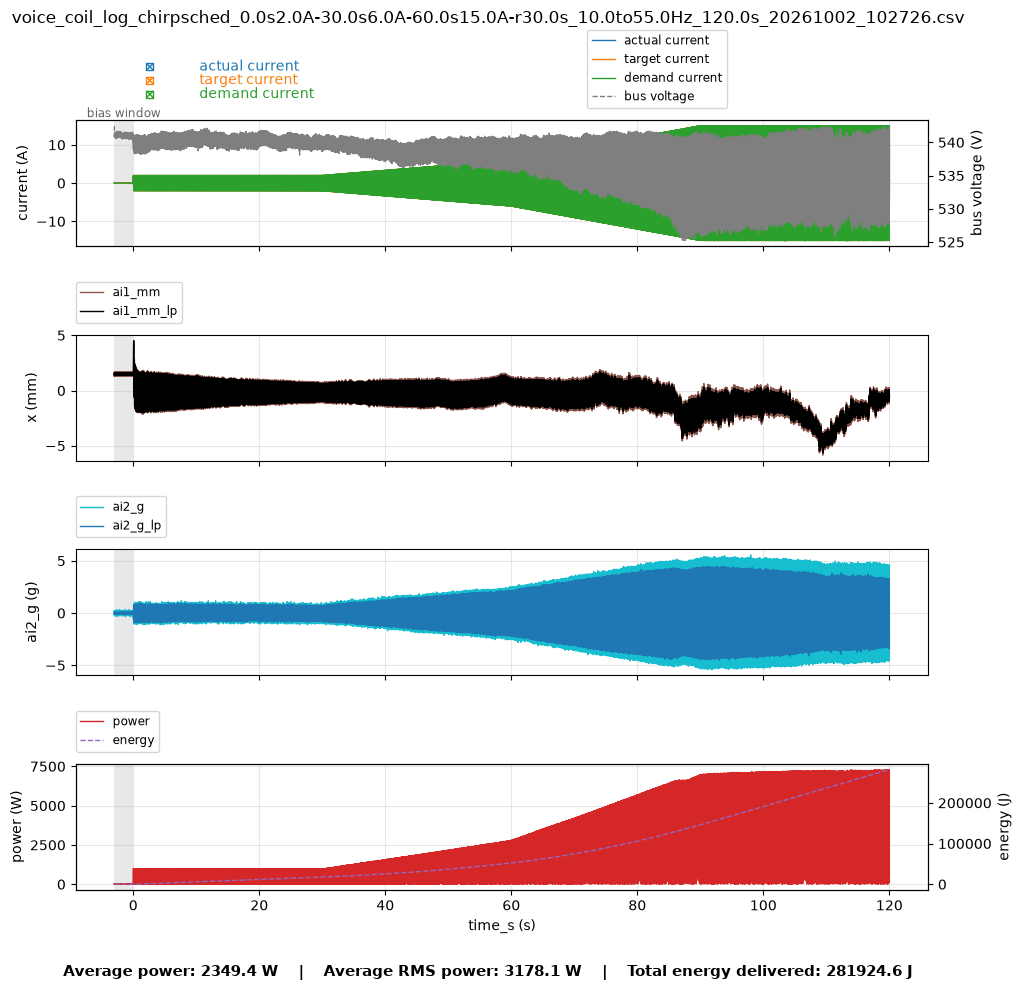

In [5]:
plot_log(RUN_FILE)